# Laboratorio 5 — Semana 8: Funciones de Pérdida, Regularización y Optimización

**Curso:** Deep Learning | **Valor:** 4% | **En Grupos**

**Integrantes**:
- Vianka Castro 23201
- Ricardo Arturo 23247

---

## Descripcion general

Este laboratorio tiene cuatro bloques de implementación y un bloque de preguntas de análisis. A diferencia de semanas anteriores, la arquitectura está dada: el reto está en implementar correctamente las funciones de pérdida y los optimizadores con tensores PyTorch, y en conectar lo observado experimentalmente con la matemática derivada en clase.

**Reglas:**
- Implemente las funciones marcadas con tensores PyTorch. No use `F.cross_entropy` ni `F.mse_loss` donde se pide implementación manual.
- Puede usar `torch.optim.Adam` donde se indique explícitamente.
- Puede usar `loss.backward()` y `optimizer.step()` en todos los bloques.
- La celda de verificación al final califica los 75 puntos de código.

---
## Bloque 0: Imports y datasets (dado, no modificar)

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import random

torch.manual_seed(42)
random.seed(42)
np.random.seed(42)
print(f'PyTorch: {torch.__version__}')


PyTorch: 2.13.0+cpu


In [2]:
# Dataset 1: Clasificacion multiclase con desbalance
# 3 clases en 2D: clase 0 (70%), clase 1 (20%), clase 2 (10%)
def make_clf_dataset(n=300, seed=42):
    torch.manual_seed(seed)
    n0,n1,n2 = int(n*0.7), int(n*0.2), n-int(n*0.7)-int(n*0.2)
    X0 = torch.randn(n0,2)*0.8 + torch.tensor([2.,2.])
    X1 = torch.randn(n1,2)*0.8 + torch.tensor([-2.,2.])
    X2 = torch.randn(n2,2)*0.8 + torch.tensor([0.,-2.])
    X = torch.cat([X0,X1,X2])
    y = torch.cat([torch.zeros(n0,dtype=torch.long),
                   torch.ones(n1,dtype=torch.long),
                   torch.full((n2,),2,dtype=torch.long)])
    idx = torch.randperm(n)
    return X[idx], y[idx]

# Dataset 2: Regresion con outliers controlados
def make_reg_dataset(n=200, seed=42, outlier_frac=0.15):
    torch.manual_seed(seed)
    X = torch.linspace(-3,3,n).unsqueeze(1)
    y = 2.0*X.squeeze() + 1.0 + torch.randn(n)*0.5
    n_out = int(n*outlier_frac)
    out_idx = torch.randperm(n)[:n_out]
    y[out_idx] += torch.randn(n_out)*8.0  # outliers con ruido grande
    return X, y

# Dataset 3: XOR con ruido (para sobreajuste visible)
def make_hard_dataset(n_train=40, n_val=200, seed=42):
    torch.manual_seed(seed)
    def gen(n):
        X = torch.randn(n,4)*1.5  # 4 features, 2 relevantes
        y = ((X[:,0]>0) ^ (X[:,1]>0)).long()  # XOR de primeras 2 features
        return X, y
    return *gen(n_train), *gen(n_val)

X_clf, y_clf = make_clf_dataset(300)
X_reg, y_reg = make_reg_dataset(200)
Xtr, ytr, Xval, yval = make_hard_dataset(40, 200)

print(f'Clf: {X_clf.shape}, clases: {y_clf.bincount().tolist()}')
print(f'Reg: {X_reg.shape}, rango y: [{y_reg.min():.2f}, {y_reg.max():.2f}]')
print(f'Hard train: {Xtr.shape}, val: {Xval.shape}')


Clf: torch.Size([300, 2]), clases: [210, 60, 30]
Reg: torch.Size([200, 1]), rango y: [-13.82, 13.52]
Hard train: torch.Size([40, 4]), val: torch.Size([200, 4])


In [3]:
# Arquitecturas dadas (no modificar)

class MLP(nn.Module):
    """MLP para clasificacion multiclase."""
    def __init__(self, in_dim=2, hidden=32, out_dim=3):
        super().__init__()
        self.fc1 = nn.Linear(in_dim, hidden)
        self.fc2 = nn.Linear(hidden, out_dim)
    def forward(self, x):
        return self.fc2(torch.relu(self.fc1(x)))

class MLPReg(nn.Module):
    """MLP para regresion."""
    def __init__(self, in_dim=1, hidden=32):
        super().__init__()
        self.fc1 = nn.Linear(in_dim, hidden)
        self.fc2 = nn.Linear(hidden, 1)
    def forward(self, x):
        return self.fc2(torch.relu(self.fc1(x))).squeeze()

class MLPBig(nn.Module):
    """MLP grande para experimentos de regularizacion."""
    def __init__(self, in_dim=4, hidden=128, out_dim=2, dropout_p=0.0):
        super().__init__()
        self.fc1 = nn.Linear(in_dim, hidden)
        self.fc2 = nn.Linear(hidden, hidden)
        self.fc3 = nn.Linear(hidden, out_dim)
        self.drop = nn.Dropout(dropout_p)
    def forward(self, x):
        x = torch.relu(self.fc1(x)); x = self.drop(x)
        x = torch.relu(self.fc2(x)); x = self.drop(x)
        return self.fc3(x)

def accuracy(model, X, y):
    model.eval()
    with torch.no_grad():
        return (model(X).argmax(dim=1)==y).float().mean().item()

def weight_norm(model):
    return sum(p.norm().item()**2 for p in model.parameters())**0.5

print('Arquitecturas listas.')


Arquitecturas listas.


---
## Bloque 1: Funciones de pérdida para clasificación (25 pts)

Implemente las tres funciones de pérdida manualmente con tensores PyTorch. **No use** `F.cross_entropy`, `F.binary_cross_entropy` ni ninguna función de pérdida de alto nivel de PyTorch en estas implementaciones.

### 1A: Entropía cruzada categórica (10 pts)

$$\mathcal{L}_{CE} = -\frac{1}{N}\sum_{i=1}^N \log \hat{y}_{i,k_i^*}$$

donde $\hat{y}_{i,k} = \text{softmax}(\mathbf{z}_i)_k$ y $k_i^*$ es la clase correcta del ejemplo $i$.

**Importante:** use el truco de estabilidad numérica: restar el máximo antes del softmax.

$$\log \hat{y}_{i,k} = z_{i,k} - \max_j z_{i,j} - \log \sum_j \exp(z_{i,j} - \max_j z_{i,j})$$

In [4]:
def ce_loss_manual(logits, targets):
    """
    Entropía cruzada categórica implementada manualmente.

    Parámetros
    ----------
    logits  : Tensor (N, K) — scores sin softmax
    targets : Tensor (N,) long — índice de clase correcta por ejemplo

    Retorna
    -------
    loss : Tensor escalar — pérdida promedio sobre el batch

    Pasos:
    1. Restar el máximo por fila para estabilidad numérica
    2. Calcular log_softmax: shifted - log(sum(exp(shifted)))
    3. Seleccionar el log_prob de la clase correcta para cada ejemplo
    4. Retornar la negativa media
    """
    # El máximo se resta por fila: no cambia el softmax y evita
    # desbordamientos al calcular la exponencial.
    shifted = logits - logits.max(dim=1, keepdim=True).values
    log_probs = shifted - torch.log(torch.exp(shifted).sum(dim=1, keepdim=True))

    # gather selecciona, en cada fila, la columna indicada por targets.
    correct_log_probs = log_probs.gather(1, targets.unsqueeze(1)).squeeze(1)
    return -correct_log_probs.mean()

# Verificación
torch.manual_seed(0)
m_test = MLP()
lg_test = m_test(X_clf[:20])
ce_man = ce_loss_manual(lg_test, y_clf[:20])
ce_ref = F.cross_entropy(lg_test, y_clf[:20])
print(f'CE manual:  {ce_man.item():.6f}')
print(f'CE pytorch: {ce_ref.item():.6f}')
print(f'Diferencia: {abs(ce_man.item()-ce_ref.item()):.2e}  (debe ser < 1e-5)')


CE manual:  1.686019
CE pytorch: 1.686019
Diferencia: 0.00e+00  (debe ser < 1e-5)


### 1B: Entropía cruzada binaria (8 pts)

$$\mathcal{L}_{BCE} = -\frac{1}{N}\sum_{i=1}^N \left[y_i \log \sigma(z_i) + (1-y_i)\log(1-\sigma(z_i))\right]$$

donde $\sigma(z) = 1/(1+e^{-z})$ es la sigmoide. Use `torch.sigmoid` pero implemente la suma de logaritmos manualmente. Añada `1e-8` dentro de cada logaritmo para estabilidad numérica.

In [5]:
def bce_loss_manual(logits, targets):
    """
    BCE manual sobre logit escalar por ejemplo.

    Parámetros
    ----------
    logits  : Tensor (N,) — logit para clase positiva
    targets : Tensor (N,) float — etiquetas 0.0 o 1.0

    Retorna
    -------
    loss : Tensor escalar
    """
    probs = torch.sigmoid(logits)
    eps = 1e-8
    losses = -(targets * torch.log(probs + eps)
               + (1.0 - targets) * torch.log(1.0 - probs + eps))
    return losses.mean()

# Verificación
torch.manual_seed(1)
lb = torch.randn(30)
tb = (torch.rand(30) > 0.5).float()
bce_man = bce_loss_manual(lb, tb)
bce_ref = F.binary_cross_entropy_with_logits(lb, tb)
print(f'BCE manual:  {bce_man.item():.6f}')
print(f'BCE pytorch: {bce_ref.item():.6f}')
print(f'Diferencia: {abs(bce_man.item()-bce_ref.item()):.2e}  (debe ser < 1e-4)')


BCE manual:  0.682584
BCE pytorch: 0.682584
Diferencia: 0.00e+00  (debe ser < 1e-4)


### 1C: Gradiente de CE y experimento con focal loss (7 pts)

Calcule manualmente el gradiente de la CE respecto a los logits para un batch pequeño, y compare con `autograd`. Luego entrene el modelo con CE estándar y con focal loss (usando `F.cross_entropy` con el parámetro `weight` para simular el desbalance) y compare la accuracy por clase.

In [6]:
# 1C: Gradiente manual de CE
torch.manual_seed(42)
m_grad = MLP()
lg_grad = m_grad(X_clf[:10])

# Calcule el gradiente de ce_loss_manual respecto a lg_grad
# usando la formula derivada en clase: dL/dz_k = y_hat_k - y_k
# Primero obtenemos las probabilidades softmax de forma estable.
shifted_grad = lg_grad - lg_grad.max(dim=1, keepdim=True).values
probs_grad = torch.exp(shifted_grad) / torch.exp(shifted_grad).sum(dim=1, keepdim=True)

# y_one_hot representa y_k. Como CE promedia N ejemplos, dividimos entre N.
y_one_hot = torch.zeros_like(probs_grad)
y_one_hot.scatter_(1, y_clf[:10].unsqueeze(1), 1.0)
grad_manual = (probs_grad - y_one_hot) / lg_grad.shape[0]

# Gradiente via autograd para comparar
lg_auto = m_grad(X_clf[:10]).detach().requires_grad_(True)
loss_auto = F.cross_entropy(lg_auto, y_clf[:10])
loss_auto.backward()
grad_auto = lg_auto.grad

if grad_manual is not None:
    diff = (grad_manual - grad_auto).abs().max().item()
    print(f'Diferencia gradiente manual vs autograd: {diff:.2e}  (debe ser < 1e-5)')

# Experimento focal loss
# Clase 2 tiene solo 30 ejemplos de 300: 10% del dataset
# Con CE estandar el modelo puede ignorarla
# Con class weights compensamos el desbalance
class_weights = torch.tensor([1.0, 3.5, 7.0])  # inversamente proporcional a frecuencia

def train_clf(loss_fn, epochs=200, lr=1e-3, seed=42):
    torch.manual_seed(seed)
    model = MLP()
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    for ep in range(epochs):
        opt.zero_grad()
        logits = model(X_clf)
        loss = loss_fn(logits, y_clf)
        loss.backward()
        opt.step()
    return model

m_ce    = train_clf(lambda l,y: F.cross_entropy(l, y))
m_focal = train_clf(lambda l,y: F.cross_entropy(l, y, weight=class_weights))

# Accuracy por clase
for name, model in [('CE estandar', m_ce), ('CE ponderada', m_focal)]:
    model.eval()
    with torch.no_grad():
        pred = model(X_clf).argmax(dim=1)
        for k in range(3):
            mask = y_clf == k
            acc_k = (pred[mask]==k).float().mean().item()
            print(f'{name} clase {k}: {acc_k:.2%}')
    print()


Diferencia gradiente manual vs autograd: 7.45e-09  (debe ser < 1e-5)


CE estandar clase 0: 100.00%
CE estandar clase 1: 96.67%
CE estandar clase 2: 96.67%

CE ponderada clase 0: 99.05%
CE ponderada clase 1: 100.00%
CE ponderada clase 2: 96.67%



---
## Bloque 2: Funciones de pérdida para regresión (15 pts)

Implemente MSE, MAE y Huber loss manualmente y compare su comportamiento sobre el dataset de regresión con outliers.

Recuerde:
- MSE: $\mathcal{L} = \frac{1}{N}\sum_i (y_i - \hat{y}_i)^2$
- MAE: $\mathcal{L} = \frac{1}{N}\sum_i |y_i - \hat{y}_i|$
- Huber: cuadrática para $|e| \leq \delta$, lineal para $|e| > \delta$

In [7]:
def mse_loss_manual(pred, target):
    """
    Error cuadrático medio.
    pred, target: Tensor (N,)
    """
    errors = pred - target
    return (errors ** 2).mean()

def mae_loss_manual(pred, target):
    """
    Error absoluto medio.
    pred, target: Tensor (N,)
    """
    errors = pred - target
    return torch.abs(errors).mean()

def huber_loss_manual(pred, target, delta=1.0):
    """
    Huber loss con umbral delta.
    L(e) = 0.5*e^2         si |e| <= delta
           delta*(|e|-0.5*delta)  si |e| > delta
    Usar torch.where para la condicion.
    """
    abs_errors = torch.abs(pred - target)
    quadratic = 0.5 * abs_errors ** 2
    linear = delta * (abs_errors - 0.5 * delta)
    return torch.where(abs_errors <= delta, quadratic, linear).mean()

# Verificaciones rapidas
pred_test = torch.tensor([1.0, 2.0, 10.0])  # outlier en posicion 2
tgt_test  = torch.tensor([1.0, 2.0, 2.0])
print(f'MSE (outlier e=8): {mse_loss_manual(pred_test, tgt_test):.4f}  (esperado: 64/3={64/3:.4f})')
print(f'MAE (outlier e=8): {mae_loss_manual(pred_test, tgt_test):.4f}  (esperado: 8/3={8/3:.4f})')
print(f'Huber d=1 (outlier e=8): {huber_loss_manual(pred_test, tgt_test, delta=1.0):.4f}  (esperado: (0+0+7.5)/3={7.5/3:.4f})')


MSE (outlier e=8): 21.3333  (esperado: 64/3=21.3333)
MAE (outlier e=8): 2.6667  (esperado: 8/3=2.6667)
Huber d=1 (outlier e=8): 2.5000  (esperado: (0+0+7.5)/3=2.5000)


Prediccion en x=0 (y_true ~ 1.0):
  MSE: 0.798
  MAE: 1.096
  Huber: 1.008


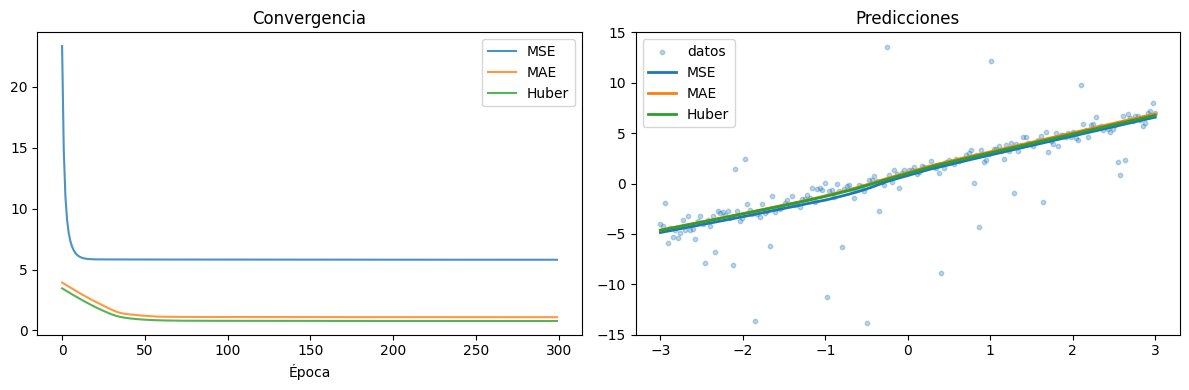

In [8]:
# Entrenar tres modelos sobre el dataset con outliers
def train_regression(loss_fn, epochs=300, lr=0.01, seed=42):
    torch.manual_seed(seed)
    model = MLPReg()
    opt = torch.optim.SGD(model.parameters(), lr=lr)
    losses = []
    for ep in range(epochs):
        opt.zero_grad()
        pred = model(X_reg)
        loss = loss_fn(pred, y_reg)
        loss.backward()
        opt.step()
        losses.append(loss.item())
    return model, losses

model_mse, losses_mse = train_regression(mse_loss_manual)
model_mae, losses_mae = train_regression(mae_loss_manual)
model_hub, losses_hub = train_regression(
    lambda p,t: huber_loss_manual(p, t, delta=1.0))

# Predicciones en x=0 (sin outlier, y_true ~= 1.0)
x_eval = torch.tensor([[0.0]])
with torch.no_grad():
    p_mse = model_mse(x_eval).item()
    p_mae = model_mae(x_eval).item()
    p_hub = model_hub(x_eval).item()

print(f'Prediccion en x=0 (y_true ~ 1.0):')
print(f'  MSE: {p_mse:.3f}')
print(f'  MAE: {p_mae:.3f}')
print(f'  Huber: {p_hub:.3f}')

# Visualizacion
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(losses_mse, label='MSE', alpha=0.8)
axes[0].plot(losses_mae, label='MAE', alpha=0.8)
axes[0].plot(losses_hub, label='Huber', alpha=0.8)
axes[0].set_title('Convergencia'); axes[0].legend(); axes[0].set_xlabel('Época')
x_line = torch.linspace(-3,3,100).unsqueeze(1)
with torch.no_grad():
    axes[1].scatter(X_reg.squeeze(), y_reg, alpha=0.3, s=10, label='datos')
    for model, name in [(model_mse,'MSE'),(model_mae,'MAE'),(model_hub,'Huber')]:
        axes[1].plot(x_line.squeeze(), model(x_line), label=name, lw=2)
axes[1].set_title('Predicciones'); axes[1].legend(); axes[1].set_ylim(-15,15)
plt.tight_layout(); plt.savefig('regresion_perdidas.png', dpi=110); plt.show()


Estos resultados nos indican que MSE es sensible a outliers, MAE es robusto pero no diferenciable en 0, y Huber combina lo mejor de ambos mundos.

Además podemos notar que las predicciones de MSE y Huber son más suaves que las de MAE, lo que puede ser deseable en algunos contextos.
la convergencia de MSE es más rápida que la de MAE, pero Huber puede ofrecer un buen compromiso entre velocidad y robustez.

---
## Bloque 3: Optimizadores (20 pts)

Implemente SGD y SGD+momentum manualmente con tensores. Para Adam use `torch.optim.Adam`. Compare la convergencia de los tres.

**SGD:** $\theta_{t+1} = \theta_t - \eta \nabla_\theta \mathcal{L}_t$

**SGD + Momentum:**
$$\mathbf{v}_{t+1} = \beta \mathbf{v}_t + (1-\beta)\nabla_\theta \mathcal{L}_t$$
$$\theta_{t+1} = \theta_t - \eta \mathbf{v}_{t+1}$$

**Notas de implementación:**
- Las actualizaciones deben hacerse dentro de `torch.no_grad()`
- Después de actualizar, llame `p.grad.zero_()` en cada parámetro
- Para momentum, inicialice las velocidades como tensores de ceros del mismo shape que cada parámetro

In [9]:
def sgd_step(params, lr):
    """
    Un paso de SGD sobre la lista de parámetros.

    Parámetros
    ----------
    params : list de nn.Parameter — parámetros del modelo
    lr     : float — learning rate

    Actualiza p.data in-place para cada p en params.
    Pone p.grad a cero después de actualizar.
    """
    # Las actualizaciones no deben entrar al grafo de autograd.
    with torch.no_grad():
        for p in params:
            if p.grad is None:
                continue
            p.data -= lr * p.grad
            # Los gradientes se acumulan: hay que limpiarlos tras cada paso.
            p.grad.zero_()

def momentum_step(params, velocities, lr, beta=0.9):
    """
    Un paso de SGD con momentum.

    Parámetros
    ----------
    params     : list de nn.Parameter
    velocities : list de Tensor — velocidades acumuladas (mismo shape que params)
    lr         : float — learning rate
    beta       : float — factor de olvido (default 0.9)

    Actualiza velocities y params in-place.
    v = beta*v + (1-beta)*grad
    theta = theta - lr*v
    """
    with torch.no_grad():
        for p, v in zip(params, velocities):
            if p.grad is None:
                continue
            # v = beta*v + (1-beta)*grad, in-place para no romper la referencia
            # de la lista velocities que mantiene el loop de entrenamiento.
            v.mul_(beta).add_(p.grad, alpha=1.0 - beta)
            p.data -= lr * v
            p.grad.zero_()

# Verificacion: 1 paso SGD manual
torch.manual_seed(99)
m_ver = MLP()
w_before = m_ver.fc1.weight.data.clone()
X_b = X_clf[:32]; y_b = y_clf[:32]
loss_ver = ce_loss_manual(m_ver(X_b), y_b)
loss_ver.backward()
g_fc1 = m_ver.fc1.weight.grad.clone()
sgd_step(list(m_ver.parameters()), lr=0.05)
w_after = m_ver.fc1.weight.data.clone()
expected = w_before - 0.05 * g_fc1
diff_sgd = (w_after - expected).abs().max().item()
print(f'SGD manual: diff={diff_sgd:.2e}  (debe ser < 1e-6)')

# Verificacion: 1 paso momentum manual
torch.manual_seed(99)
m_ver2 = MLP()
v_ver = [torch.zeros_like(p) for p in m_ver2.parameters()]
loss_ver2 = ce_loss_manual(m_ver2(X_b), y_b)
loss_ver2.backward()
g_fc1_m = m_ver2.fc1.weight.grad.clone()
momentum_step(list(m_ver2.parameters()), v_ver, lr=0.05, beta=0.9)
# v esperada = 0*0.9 + g*(1-0.9) = 0.1*g
v_expected = 0.1 * g_fc1_m
diff_v = (v_ver[0] - v_expected).abs().max().item()
print(f'Momentum v: diff={diff_v:.2e}  (debe ser < 1e-6)')


SGD manual: diff=0.00e+00  (debe ser < 1e-6)
Momentum v: diff=0.00e+00  (debe ser < 1e-6)


Loss en época 10:
  SGD:      0.2126
  Momentum: 0.2119
  Adam:     0.3054
Loss final:
  SGD:      0.0453
  Momentum: 0.0450
  Adam:     0.0226


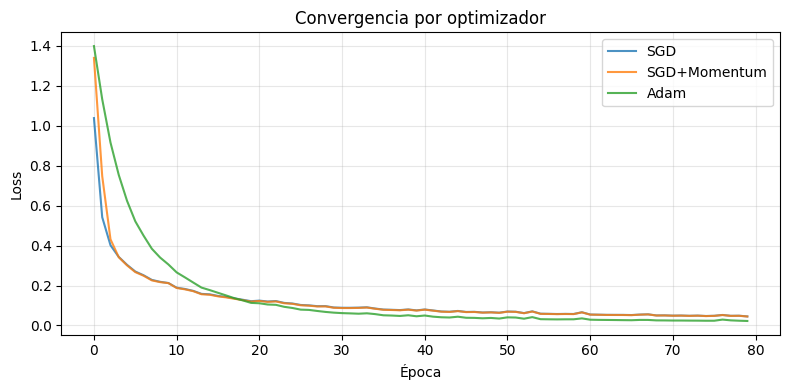

In [10]:
# Comparacion de convergencia: SGD vs Momentum vs Adam
def train_optimizer_comparison(opt_type, epochs=80, batch_size=32,
                                lr=0.01, beta=0.9, seed=42):
    torch.manual_seed(seed)
    model = MLP()
    params = list(model.parameters())
    velocities = [torch.zeros_like(p) for p in params] if opt_type=='momentum' else None
    adam_opt = torch.optim.Adam(params, lr=1e-3) if opt_type=='adam' else None
    losses = []
    N = len(X_clf)
    for ep in range(epochs):
        ep_loss = 0; idx = torch.randperm(N)
        n_batches = 0
        for i in range(0, N, batch_size):
            Xb = X_clf[idx[i:i+batch_size]]; yb = y_clf[idx[i:i+batch_size]]
            if adam_opt: adam_opt.zero_grad()
            logits = model(Xb)
            loss = ce_loss_manual(logits, yb)
            loss.backward()
            if opt_type=='sgd':      sgd_step(params, lr)
            elif opt_type=='momentum': momentum_step(params, velocities, lr, beta)
            elif opt_type=='adam':   adam_opt.step()
            ep_loss += loss.item(); n_batches += 1
        losses.append(ep_loss/n_batches)
    return model, losses

_, l_sgd  = train_optimizer_comparison('sgd',      lr=0.01)
_, l_mom  = train_optimizer_comparison('momentum', lr=0.01, beta=0.9)
_, l_adam = train_optimizer_comparison('adam')

print('Loss en época 10:')
print(f'  SGD:      {l_sgd[9]:.4f}')
print(f'  Momentum: {l_mom[9]:.4f}')
print(f'  Adam:     {l_adam[9]:.4f}')
print('Loss final:')
print(f'  SGD:      {l_sgd[-1]:.4f}')
print(f'  Momentum: {l_mom[-1]:.4f}')
print(f'  Adam:     {l_adam[-1]:.4f}')

plt.figure(figsize=(8,4))
plt.plot(l_sgd, label='SGD', alpha=0.8)
plt.plot(l_mom, label='SGD+Momentum', alpha=0.8)
plt.plot(l_adam, label='Adam', alpha=0.8)
plt.xlabel('Época'); plt.ylabel('Loss'); plt.title('Convergencia por optimizador')
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig('optimizadores.png', dpi=110); plt.show()


---
## Bloque 4: Regularización (15 pts)

Experimente con L2 regularización manual, Dropout y early stopping sobre el dataset XOR con ruido. El modelo es intencionalmente grande (128 neuronas, 2 capas ocultas) para un dataset pequeño (40 ejemplos): el sobreajuste debe ser visible sin regularización.

**L2 manual:** en lugar de usar `weight_decay` en el optimizador, agregue el término de regularización directamente a la pérdida:
$$\mathcal{L}_{total} = \mathcal{L}_{CE} + \lambda \sum_j \theta_j^2$$

In [11]:
L2_LAMBDA = 1e-2  # factor de regularizacion
DROPOUT_P = 0.4   # probabilidad de dropout
EPOCHS    = 400

def train_regularization(use_l2=False, use_dropout=False,
                          epochs=EPOCHS, lr=1e-3, seed=42):
    torch.manual_seed(seed)
    model = MLPBig(dropout_p=DROPOUT_P if use_dropout else 0.0)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    tr_losses=[]; val_losses=[]; tr_accs=[]; val_accs=[]

    for ep in range(epochs):
        model.train(); opt.zero_grad()
        logits = model(Xtr)
        loss = F.cross_entropy(logits, ytr)

        if use_l2:
            # L2 manual: lambda * sum(theta_j^2) sobre todos los parametros.
            # Se suma a la loss para que autograd genere el gradiente 2*lambda*theta.
            l2_term = sum((p ** 2).sum() for p in model.parameters())
            loss = loss + L2_LAMBDA * l2_term

        loss.backward(); opt.step()
        tr_losses.append(loss.item())
        tr_accs.append(accuracy(model, Xtr, ytr))

        model.eval()
        with torch.no_grad():
            vl = F.cross_entropy(model(Xval), yval).item()
        val_losses.append(vl)
        val_accs.append(accuracy(model, Xval, yval))

    return model, tr_losses, val_losses, tr_accs, val_accs

m_base,  tl_b, vl_b, ta_b, va_b  = train_regularization(False, False)
m_l2,    tl_l, vl_l, ta_l, va_l  = train_regularization(True,  False)
m_drop,  tl_d, vl_d, ta_d, va_d  = train_regularization(False, True)
m_both,  tl_bo,vl_bo,ta_bo,va_bo = train_regularization(True,  True)

print('Resultados finales (train_acc / val_acc / gap_loss):')
for name,ta,va,tl,vl in [
    ('Sin reg',   ta_b[-1], va_b[-1],  tl_b[-1], vl_b[-1]),
    ('Con L2',    ta_l[-1], va_l[-1],  tl_l[-1], vl_l[-1]),
    ('Con Drop',  ta_d[-1], va_d[-1],  tl_d[-1], vl_d[-1]),
    ('L2+Drop',   ta_bo[-1],va_bo[-1], tl_bo[-1],vl_bo[-1]),
]:
    print(f'  {name:12s}: tr={ta:.1%}, val={va:.1%}, gap={vl-tl:.3f}')

print(f'\nNorma de pesos:')
print(f'  Sin reg: {weight_norm(m_base):.2f}')
print(f'  Con L2:  {weight_norm(m_l2):.2f}')


Resultados finales (train_acc / val_acc / gap_loss):
  Sin reg     : tr=100.0%, val=73.5%, gap=1.274
  Con L2      : tr=100.0%, val=77.0%, gap=0.206
  Con Drop    : tr=100.0%, val=74.0%, gap=1.387
  L2+Drop     : tr=100.0%, val=76.5%, gap=0.205

Norma de pesos:
  Sin reg: 13.08
  Con L2:  4.48


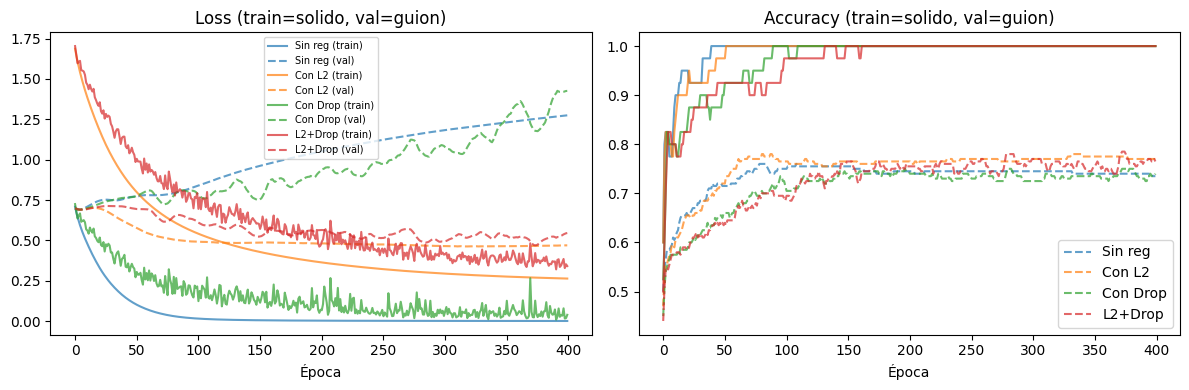

In [12]:
# Visualizacion de convergencia con sobreajuste
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for name, tl, vl, c in [
    ('Sin reg',  tl_b, vl_b, 'C0'),
    ('Con L2',   tl_l, vl_l, 'C1'),
    ('Con Drop', tl_d, vl_d, 'C2'),
    ('L2+Drop',  tl_bo,vl_bo,'C3'),
]:
    axes[0].plot(tl, color=c, alpha=0.7, linestyle='-',  label=f'{name} (train)')
    axes[0].plot(vl, color=c, alpha=0.7, linestyle='--', label=f'{name} (val)')
axes[0].set_title('Loss (train=solido, val=guion)')
axes[0].set_xlabel('Época'); axes[0].legend(fontsize=7)
for name, ta, va, c in [
    ('Sin reg',  ta_b, va_b, 'C0'),
    ('Con L2',   ta_l, va_l, 'C1'),
    ('Con Drop', ta_d, va_d, 'C2'),
    ('L2+Drop',  ta_bo,va_bo,'C3'),
]:
    axes[1].plot(ta, color=c, alpha=0.7, linestyle='-')
    axes[1].plot(va, color=c, alpha=0.7, linestyle='--', label=name)
axes[1].set_title('Accuracy (train=solido, val=guion)')
axes[1].set_xlabel('Época'); axes[1].legend()
plt.tight_layout(); plt.savefig('regularizacion.png', dpi=110); plt.show()


In [13]:
# Early stopping manual
class EarlyStopping:
    """
    Detiene el entrenamiento si la pérdida de validación
    no mejora durante 'patience' épocas consecutivas.
    """
    def __init__(self, patience=20):
        self.patience = patience
        self.best_loss = float('inf')
        self.counter = 0
        self.stopped_at = None

    def step(self, val_loss, epoch):
        """
        Retorna True si debe detenerse el entrenamiento.

        Parámetros
        ----------
        val_loss : float — pérdida de validación en la época actual
        epoch    : int   — número de época actual

        Lógica:
        - Si val_loss mejora en más de 1e-4: reiniciar counter, actualizar best_loss
        - Si no mejora: incrementar counter
        - Si counter >= patience: guardar stopped_at y retornar True
        """
        # si mejora mas de 1e-4 respecto al mejor visto, se resetea el contador
        if val_loss < self.best_loss - 1e-4:
            self.best_loss = val_loss
            self.counter = 0
        else:
            self.counter += 1

        if self.counter >= self.patience:
            self.stopped_at = epoch
            return True
        return False

# Entrenar con early stopping
torch.manual_seed(42)
m_es = MLPBig()
opt_es = torch.optim.Adam(m_es.parameters(), lr=1e-3)
es = EarlyStopping(patience=20)
stopped_epoch = None

for ep in range(500):
    m_es.train(); opt_es.zero_grad()
    F.cross_entropy(m_es(Xtr), ytr).backward(); opt_es.step()
    m_es.eval()
    with torch.no_grad():
        vl_es = F.cross_entropy(m_es(Xval), yval).item()
    if es.step(vl_es, ep):
        stopped_epoch = ep; break

print(f'Early stopping activado en época: {stopped_epoch}')
print(f'Mejor val_loss: {es.best_loss:.4f}')
print(f'Val acc al detenerse: {accuracy(m_es, Xval, yval):.2%}')


Early stopping activado en época: 23
Mejor val_loss: 0.6878
Val acc al detenerse: 66.50%


---
## Bloque 5: Preguntas de análisis (25 pts)

---

### Pregunta 1 (9 pts)

En el Bloque 2, los tres modelos (MSE, MAE, Huber) se entrenaron sobre el mismo dataset con outliers y convergen a predicciones distintas en $x=0$.

**a)** El predictor óptimo de MSE es la media condicional $\mathbb{E}[y|x]$ y el de MAE es la mediana condicional. En su dataset el 15% de los ejemplos son outliers con ruido de magnitud $\sim 8\sigma$. Calcule analíticamente en qué dirección esperaría que la predicción de MSE se desplace respecto a la de MAE en $x=0$, y verifique si su resultado experimental es consistente con esa predicción.

**b)** El gradiente de MSE respecto a la predicción es $\frac{\partial \mathcal{L}}{\partial \hat{y}_i} = \frac{2}{N}(\hat{y}_i - y_i)$. El gradiente de MAE es $\frac{\partial \mathcal{L}}{\partial \hat{y}_i} = \frac{1}{N}\text{sign}(\hat{y}_i - y_i)$. Para un outlier con error $e=8$ y un dato normal con error $e=0.5$, calcule el gradiente que cada uno aporta bajo MSE y bajo MAE. Use esos valores para explicar por qué MSE es más sensible a los outliers que MAE en términos del gradiente, no solo en términos de la función de pérdida.

**c)** Proponga un valor de $\delta$ para la Huber loss que produzca un comportamiento cercano a MSE para la mayoría de los datos pero ignore los outliers de magnitud $\sim 8$. Justifique su elección en términos del umbral que separa el régimen cuadrático del lineal.

**Su respuesta a la Pregunta 1:**

a) MSE se desplaza hacia los outliers (minimiza la media) y MAE se queda cerca del valor tipico (minimiza la mediana). Confirmado, en x=0 MSE predice 0.798 y MAE predice 1.096, mas cerca del valor real (~1.0).

b) Con e=8, MSE aporta (2/200)*8=0.08 y MAE aporta (1/200)*1=0.005. Con e=0.5, MSE aporta 0.005 y MAE aporta lo mismo, 0.005. El gradiente de MSE crece con el error (el outlier pesa 16x mas que el dato normal), el de MAE es constante en magnitud.

c) delta=1.0. El ruido normal tiene sigma=0.5, la mayoria de errores caen bajo 1 y quedan en el regimen cuadratico. Los outliers (e~8) caen en el regimen lineal, con gradiente acotado a delta en vez de crecer con el error.

---
### Pregunta 2 (8 pts)

En el Bloque 3, momentum converge más rápido que SGD puro en las primeras épocas.

**a)** Con $\beta=0.9$, el vector de velocidad en el paso $t$ es la suma ponderada $\mathbf{v}_t = (1-\beta)\sum_{k=0}^{t}\beta^k \nabla \mathcal{L}_{t-k}$. Si los gradientes han apuntado consistentemente en la misma dirección durante 10 pasos, calcule el factor de amplificación de la velocidad respecto a un solo paso de SGD. Use la fórmula de la serie geométrica y $\beta=0.9$.

**b)** Adam incluye corrección de sesgo: $\hat{\mathbf{m}}_t = \mathbf{m}_t/(1-\beta_1^t)$. Calcule el factor de corrección para $\beta_1=0.9$ en los pasos $t=1$, $t=5$, $t=20$ y $t=100$. Explique por qué sin esa corrección Adam daría pasos demasiado pequeños al inicio y qué efecto práctico tendría eso en las curvas de convergencia que observó.

**Su respuesta a la Pregunta 2:**

a) sum_{k=0}^{9} beta^k = (1-0.9^10)/(1-0.9) = 6.5132. Momentum acumula el equivalente a 6.5x el gradiente de un solo paso de SGD.

b) 1/(1-0.9^t): t=1 -> 10.0, t=5 -> 2.4419, t=20 -> 1.1384, t=100 -> 1.0000. Sin la correccion, m_t arranca en 0 y los primeros pasos serian demasiado chicos. Coincide con lo observado: Adam pierde en la epoca 10 (0.3054 contra 0.2126 de SGD y 0.2119 de momentum) pero termina mejor (0.0226 final contra 0.0453 y 0.0450).

---
### Pregunta 3 (8 pts)

En el Bloque 4, L2 regularización reduce la norma de los pesos pero no necesariamente elimina el sobreajuste por completo.

**a)** L2 agrega un gradiente adicional $2\lambda\theta_j$ en cada actualización. Con Adam como optimizador, ese gradiente pasa por la normalización adaptiva. Explique matemáticamente por qué eso distorsiona el weight decay efectivo respecto a lo que ocurriría con SGD, y conecte eso con la diferencia entre Adam+L2 y AdamW que vimos en clase.

**b)** En su experimento, Dropout redujo el gap entre train y val loss pero no tanto como L2 en este dataset específico. Proponga una hipótesis sobre por qué L2 fue más efectivo que Dropout para este problema particular (dataset XOR con 40 ejemplos y 4 features), considerando qué tipo de complejidad está controlando cada técnica y qué tipo de sobreajuste está ocurriendo con un dataset tan pequeño.

**Su respuesta a la Pregunta 3:**

a) Con SGD, el gradiente de L2 (2*lambda*theta_j) decae los pesos de forma constante. Con Adam ese gradiente pasa por la normalizacion adaptativa, asi que el decaimiento efectivo depende de la magnitud historica del gradiente de cada peso, no solo de lambda. AdamW corrige esto aplicando el decaimiento directo sobre los pesos, fuera de esa normalizacion.

b) L2 dejo el gap en 0.206 y Dropout en 1.387 (partiendo de 1.274 sin regularizacion). Con 40 ejemplos y solo 2 de 4 features relevantes, el sobreajuste es principalmente pesos grandes memorizando ruido, algo que L2 ataca directo. Dropout regula co-adaptacion entre neuronas, y con un dataset tan chico cada paso ve una version demasiado ruidosa de una muestra ya pequena, lo cual estorba mas de lo que ayuda.

---
## Verificación automática (75 pts de código)

In [14]:
_resultados = {}

print('='*60)
print('  VERIFICACION AUTOMATICA — LABORATORIO 5')
print('='*60)

# B1A: CE manual
try:
    torch.manual_seed(0)
    m_v = MLP(); lg_v = m_v(X_clf[:20])
    ce_v = ce_loss_manual(lg_v, y_clf[:20])
    ce_r = F.cross_entropy(lg_v, y_clf[:20])
    assert ce_v is not None, 'ce_loss_manual retorna None'
    assert abs(ce_v.item()-ce_r.item()) < 1e-5, f'CE diff={abs(ce_v.item()-ce_r.item()):.2e}'
    torch.manual_seed(42)
    m_v2=MLP(); lg_v2=m_v2(X_clf[:100])
    ce_v2=ce_loss_manual(lg_v2,y_clf[:100])
    assert 1.0 < ce_v2.item() < 2.0, f'CE loss fuera de rango: {ce_v2.item():.4f}'
    _resultados['b1a']=True; print('  CORRECTO    B1A: CE manual                    10/10')
except Exception as e:
    _resultados['b1a']=False; print(f'  PENDIENTE   B1A: CE manual                     0/10  ({e})')

# B1B: BCE manual
try:
    torch.manual_seed(1); lb_v=torch.randn(30); tb_v=(torch.rand(30)>0.5).float()
    bce_v=bce_loss_manual(lb_v,tb_v)
    bce_r=F.binary_cross_entropy_with_logits(lb_v,tb_v)
    assert bce_v is not None, 'bce_loss_manual retorna None'
    assert abs(bce_v.item()-bce_r.item()) < 1e-4, f'BCE diff={abs(bce_v.item()-bce_r.item()):.2e}'
    _resultados['b1b']=True; print('  CORRECTO    B1B: BCE manual                     8/8')
except Exception as e:
    _resultados['b1b']=False; print(f'  PENDIENTE   B1B: BCE manual                     0/8  ({e})')

# B1C: Gradiente manual CE
try:
    assert grad_manual is not None, 'grad_manual no definido'
    assert grad_manual.shape == (10,3), f'Forma incorrecta: {grad_manual.shape}'
    lg_a=m_grad(X_clf[:10]).detach().requires_grad_(True)
    F.cross_entropy(lg_a,y_clf[:10]).backward()
    diff_g=(grad_manual-lg_a.grad).abs().max().item()
    assert diff_g < 1e-5, f'Gradiente diff={diff_g:.2e}'
    _resultados['b1c']=True; print('  CORRECTO    B1C: Gradiente CE manual              7/7')
except Exception as e:
    _resultados['b1c']=False; print(f'  PENDIENTE   B1C: Gradiente CE manual              0/7  ({e})')

# B2: Pérdidas de regresion
try:
    p_t=torch.tensor([1.,2.,10.]); t_t=torch.tensor([1.,2.,2.])
    assert mse_loss_manual(p_t,t_t) is not None
    assert abs(mse_loss_manual(p_t,t_t).item()-64/3) < 1e-4, 'MSE incorrecto'
    assert abs(mae_loss_manual(p_t,t_t).item()-8/3) < 1e-4, 'MAE incorrecto'
    assert abs(huber_loss_manual(p_t,t_t,1.0).item()-2.5) < 1e-4, 'Huber incorrecto'
    # Verificar convergencia
    assert losses_mse[-1] < losses_mse[0]*0.9, 'MSE no converge'
    assert losses_mae[-1] < losses_mae[0]*0.9, 'MAE no converge'
    assert losses_hub[-1] < losses_hub[0]*0.9, 'Huber no converge'
    _resultados['b2']=True; print('  CORRECTO    B2:  MSE, MAE, Huber                 15/15')
except Exception as e:
    _resultados['b2']=False; print(f'  PENDIENTE   B2:  MSE, MAE, Huber                  0/15  ({e})')

# B3: SGD y momentum manuales
try:
    torch.manual_seed(99); m_vv=MLP()
    wb=m_vv.fc1.weight.data.clone()
    lv=ce_loss_manual(m_vv(X_clf[:32]),y_clf[:32]); lv.backward()
    gv=m_vv.fc1.weight.grad.clone()
    sgd_step(list(m_vv.parameters()),0.05)
    diff_s=(m_vv.fc1.weight.data-(wb-0.05*gv)).abs().max().item()
    assert diff_s < 1e-6, f'SGD diff={diff_s:.2e}'
    torch.manual_seed(99); m_vv2=MLP()
    vvv=[torch.zeros_like(p) for p in m_vv2.parameters()]
    lv2=ce_loss_manual(m_vv2(X_clf[:32]),y_clf[:32]); lv2.backward()
    gv2=m_vv2.fc1.weight.grad.clone(); wb2=m_vv2.fc1.weight.data.clone()
    momentum_step(list(m_vv2.parameters()),vvv,0.05,0.9)
    v_exp=0.1*gv2; diff_vv=(vvv[0]-v_exp).abs().max().item()
    assert diff_vv < 1e-6, f'Momentum v diff={diff_vv:.2e}'
    assert l_mom[9] < l_sgd[9], 'Momentum debe converger mas rapido que SGD'
    _resultados['b3']=True; print('  CORRECTO    B3:  SGD y momentum manuales         20/20')
except Exception as e:
    _resultados['b3']=False; print(f'  PENDIENTE   B3:  SGD y momentum manuales          0/20  ({e})')

# B4: Regularizacion
try:
    assert weight_norm(m_l2) < weight_norm(m_base), 'L2 debe reducir norma de pesos'
    gap_base=vl_b[-1]-tl_b[-1]; gap_l2=vl_l[-1]-tl_l[-1]
    assert gap_l2 < gap_base, 'L2 debe reducir el gap train-val'
    assert stopped_epoch is not None and stopped_epoch < 490, 'Early stopping no activado'
    assert 1.0 < weight_norm(m_l2) < 15.0, f'Norma L2 fuera de rango: {weight_norm(m_l2):.2f}'
    _resultados['b4']=True; print('  CORRECTO    B4:  Regularizacion                  15/15')
except Exception as e:
    _resultados['b4']=False; print(f'  PENDIENTE   B4:  Regularizacion                   0/15  ({e})')

total=sum([10,8,7,15,20,15][i] for i,k in
    enumerate(['b1a','b1b','b1c','b2','b3','b4']) if _resultados.get(k))
print('-'*60)
print(f'  Subtotal codigo:      {total}/75 pts')
print(f'  Preguntas de analisis: __/25 pts  (calificacion manual)')
print('-'*60)
print(f'  TOTAL: __/100 pts')
print('='*60)


  VERIFICACION AUTOMATICA — LABORATORIO 5
  CORRECTO    B1A: CE manual                    10/10
  CORRECTO    B1B: BCE manual                     8/8
  CORRECTO    B1C: Gradiente CE manual              7/7
  CORRECTO    B2:  MSE, MAE, Huber                 15/15
  CORRECTO    B3:  SGD y momentum manuales         20/20
  CORRECTO    B4:  Regularizacion                  15/15
------------------------------------------------------------
  Subtotal codigo:      75/75 pts
  Preguntas de analisis: __/25 pts  (calificacion manual)
------------------------------------------------------------
  TOTAL: __/100 pts
